In [1]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 5: Feature Engineering
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load cleaned dataset from Phase 3
df = pd.read_csv('../data/APL_Logistics_cleaned.csv')

print(f"✅ Cleaned dataset loaded")
print(f"📊 Starting shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns available for feature engineering:")
print(df.columns.tolist())

✅ Cleaned dataset loaded
📊 Starting shape: 180,519 rows × 24 columns

Columns available for feature engineering:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Product Price', 'Shipping Mode']


In [2]:
# ===== FEATURE 1: SHIPPING PRESSURE INDEX =====
# Logic: When scheduled days are LOW but quantity is HIGH, operations face pressure
# High pressure → higher chance of late delivery

# Formula: quantity / (scheduled_days + 1)
# +1 prevents division by zero
# Higher value = more pressure per day

df['Shipping_Pressure_Index'] = df['Order Item Quantity'] / (df['Days for shipment (scheduled)'] + 1)

print("✅ Feature 1 Created: Shipping_Pressure_Index")
print(f"\n📊 Statistics:")
print(df['Shipping_Pressure_Index'].describe())

# Validate: does it correlate with late risk?
correlation = df['Shipping_Pressure_Index'].corr(df['Late_delivery_risk'])
print(f"\n🎯 Correlation with Late_delivery_risk: {correlation:.4f}")
print(f"💡 INTERPRETATION: Higher pressure → {'more' if correlation > 0 else 'less'} late deliveries")

✅ Feature 1 Created: Shipping_Pressure_Index

📊 Statistics:
count    180519.000000
mean          0.672111
std           0.686297
min           0.200000
25%           0.200000
50%           0.400000
75%           1.000000
max           5.000000
Name: Shipping_Pressure_Index, dtype: float64

🎯 Correlation with Late_delivery_risk: 0.1267
💡 INTERPRETATION: Higher pressure → more late deliveries


In [3]:
# ===== FEATURE 2: SHIPPING MODE RISK FLAG =====
# Based on Phase 4 insight: faster modes have higher late rates
# We create a numeric risk score for each mode

# Calculate actual late rate per mode
mode_risk_map = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().to_dict()
print("📊 Mode → Late Rate mapping:")
for mode, rate in sorted(mode_risk_map.items(), key=lambda x: x[1], reverse=True):
    print(f"   {mode}: {rate:.3f} ({rate*100:.1f}%)")

# Create the feature
df['Mode_Risk_Score'] = df['Shipping Mode'].map(mode_risk_map)

# Also create a binary flag for "express" modes (faster, higher risk)
df['Is_Express_Mode'] = df['Shipping Mode'].isin(['Same Day', 'First Class']).astype(int)

print(f"\n✅ Feature 2 Created: Mode_Risk_Score + Is_Express_Mode")
print(f"📊 Is_Express_Mode distribution: {df['Is_Express_Mode'].value_counts().to_dict()}")

📊 Mode → Late Rate mapping:
   First Class: 0.953 (95.3%)
   Second Class: 0.766 (76.6%)
   Same Day: 0.457 (45.7%)
   Standard Class: 0.381 (38.1%)

✅ Feature 2 Created: Mode_Risk_Score + Is_Express_Mode
📊 Is_Express_Mode distribution: {0: 142968, 1: 37551}


In [4]:
# ===== FEATURE 3: REGIONAL CONGESTION INDICATOR =====
# Some regions consistently have more delays — capture this signal

# Risk score by Market
market_risk_map = df.groupby('Market')['Late_delivery_risk'].mean().to_dict()
df['Market_Risk_Score'] = df['Market'].map(market_risk_map)

# Risk score by Order Region (more granular)
region_risk_map = df.groupby('Order Region')['Late_delivery_risk'].mean().to_dict()
df['Region_Risk_Score'] = df['Order Region'].map(region_risk_map)

print("✅ Feature 3 Created: Market_Risk_Score + Region_Risk_Score")
print("\n📊 Market risk scores:")
for market, score in sorted(market_risk_map.items(), key=lambda x: x[1], reverse=True):
    print(f"   {market}: {score:.3f}")

✅ Feature 3 Created: Market_Risk_Score + Region_Risk_Score

📊 Market risk scores:
   Europe: 0.552
   Pacific Asia: 0.550
   USCA: 0.548
   Africa: 0.546
   LATAM: 0.544


In [5]:
# ===== FEATURE 4: ORDER COMPLEXITY SCORE =====
# Combine multiple complexity signals into one feature
# More complex orders are harder to deliver on time

# Components:
# 1. Quantity (more items = more work)
# 2. High product price (high-value = special handling)
# 3. High discount rate (promotional rush)
# 4. Express shipping needed (time pressure)

# Normalize each component to 0-1 scale
df['Norm_Quantity'] = (df['Order Item Quantity'] - df['Order Item Quantity'].min()) / \
                      (df['Order Item Quantity'].max() - df['Order Item Quantity'].min())

df['Norm_ProductPrice'] = (df['Product Price'] - df['Product Price'].min()) / \
                          (df['Product Price'].max() - df['Product Price'].min())

df['Norm_DiscountRate'] = df['Order Item Discount Rate']  # Already 0-1

# Weighted complexity score
df['Order_Complexity_Score'] = (
    0.30 * df['Norm_Quantity'] +
    0.25 * df['Norm_ProductPrice'] +
    0.20 * df['Norm_DiscountRate'] +
    0.25 * df['Is_Express_Mode']
)

# Drop the intermediate norm columns (we don't need them as features)
df = df.drop(columns=['Norm_Quantity', 'Norm_ProductPrice', 'Norm_DiscountRate'])

print("✅ Feature 4 Created: Order_Complexity_Score")
print(f"\n📊 Score statistics:")
print(df['Order_Complexity_Score'].describe())

correlation = df['Order_Complexity_Score'].corr(df['Late_delivery_risk'])
print(f"\n🎯 Correlation with Late_delivery_risk: {correlation:.4f}")

✅ Feature 4 Created: Order_Complexity_Score

📊 Score statistics:
count    180519.000000
mean          0.173398
std           0.144596
min           0.000000
25%           0.048994
50%           0.112307
75%           0.289025
max           0.611308
Name: Order_Complexity_Score, dtype: float64

🎯 Correlation with Late_delivery_risk: 0.1994


In [6]:
# ===== FEATURE 5: HIGH DISCOUNT FLAG =====
# Heavily discounted items often have promotional rush → late delivery risk

df['Is_High_Discount'] = (df['Order Item Discount Rate'] > 0.15).astype(int)

# Also create discount bucket as ordinal
df['Discount_Severity'] = pd.cut(
    df['Order Item Discount Rate'],
    bins=[-0.01, 0.05, 0.10, 0.15, 0.20, 1.0],
    labels=[0, 1, 2, 3, 4]  # Ordinal: 0=low, 4=very high
).astype(int)

print("✅ Feature 5 Created: Is_High_Discount + Discount_Severity")
print(f"\n📊 Is_High_Discount distribution: {df['Is_High_Discount'].value_counts().to_dict()}")
print(f"📊 Discount_Severity distribution:")
print(df['Discount_Severity'].value_counts().sort_index())

✅ Feature 5 Created: Is_High_Discount + Discount_Severity

📊 Is_High_Discount distribution: {0: 130374, 1: 50145}
📊 Discount_Severity distribution:
Discount_Severity
0    60171
1    40116
2    30087
3    40116
4    10029
Name: count, dtype: int64


In [7]:
# ===== FEATURE 6: PROFIT-BASED FEATURES =====

# Flag for loss-making orders (negative profit)
df['Is_Loss_Order'] = (df['Order Profit Per Order'] < 0).astype(int)

# Profit per quantity ratio
df['Profit_Per_Unit'] = df['Order Profit Per Order'] / (df['Order Item Quantity'] + 1)

# Profit margin (already a ratio, but ensure no NaN)
df['Profit_Margin'] = df['Order Item Profit Ratio'].fillna(0)

print("✅ Feature 6 Created: Profit indicators")
print(f"\n📊 Loss-making orders: {df['Is_Loss_Order'].sum():,} ({df['Is_Loss_Order'].mean()*100:.1f}%)")
print(f"📊 Profit_Per_Unit range: {df['Profit_Per_Unit'].min():.2f} to {df['Profit_Per_Unit'].max():.2f}")

✅ Feature 6 Created: Profit indicators

📊 Loss-making orders: 33,784 (18.7%)
📊 Profit_Per_Unit range: -2137.49 to 455.90


In [8]:
# ===== FEATURE 7: SALES VALUE CATEGORY =====
# Categorize orders by value

df['Sales_Category'] = pd.cut(
    df['Sales'],
    bins=[0, 50, 150, 300, 500, 10000],
    labels=[0, 1, 2, 3, 4]  # 0=small, 4=very large
).astype(int)

print("✅ Feature 7 Created: Sales_Category")
print(f"\n📊 Sales Category distribution:")
sales_dist = df['Sales_Category'].value_counts().sort_index()
labels = ['Small (<$50)', 'Medium ($50-150)', 'Large ($150-300)', 
         'Very Large ($300-500)', 'Premium ($500+)']
for cat, count in zip(labels, sales_dist):
    print(f"   {cat}: {count:,}")

✅ Feature 7 Created: Sales_Category

📊 Sales Category distribution:
   Small (<$50): 16,379
   Medium ($50-150): 63,248
   Large ($150-300): 74,953
   Very Large ($300-500): 24,967
   Premium ($500+): 972


In [9]:
# ===== FEATURE 8: CATEGORY & DEPARTMENT RISK SCORES =====

cat_risk_map = df.groupby('Category Name')['Late_delivery_risk'].mean().to_dict()
df['Category_Risk_Score'] = df['Category Name'].map(cat_risk_map)

dept_risk_map = df.groupby('Department Name')['Late_delivery_risk'].mean().to_dict()
df['Department_Risk_Score'] = df['Department Name'].map(dept_risk_map)

print("✅ Feature 8 Created: Category_Risk_Score + Department_Risk_Score")
print(f"\n📊 Top 5 risky categories:")
top_risky = sorted(cat_risk_map.items(), key=lambda x: x[1], reverse=True)[:5]
for cat, score in top_risky:
    print(f"   {cat}: {score:.3f}")

✅ Feature 8 Created: Category_Risk_Score + Department_Risk_Score

📊 Top 5 risky categories:
   Golf Bags & Carts: 0.689
   Lacrosse: 0.601
   Pet Supplies: 0.589
   Cameras: 0.581
   Strength Training: 0.577


In [10]:
# ===== FEATURE 9: PAYMENT TYPE FLAGS =====

# Convert Type (payment method) to risk-aware features
payment_risk_map = df.groupby('Type')['Late_delivery_risk'].mean().to_dict()
df['Payment_Risk_Score'] = df['Type'].map(payment_risk_map)

# Binary flags for each payment type
df['Is_Cash_Payment'] = (df['Type'] == 'CASH').astype(int)
df['Is_Transfer_Payment'] = (df['Type'] == 'TRANSFER').astype(int)

print("✅ Feature 9 Created: Payment risk features")
print(f"\n📊 Payment type breakdown:")
for ptype, risk in sorted(payment_risk_map.items(), key=lambda x: x[1], reverse=True):
    count = (df['Type'] == ptype).sum()
    print(f"   {ptype}: {risk:.3f} risk ({count:,} orders)")

✅ Feature 9 Created: Payment risk features

📊 Payment type breakdown:
   PAYMENT: 0.575 risk (41,725 orders)
   DEBIT: 0.572 risk (69,295 orders)
   CASH: 0.566 risk (19,616 orders)
   TRANSFER: 0.485 risk (49,883 orders)


In [11]:
# ===== FEATURE 10: CUSTOMER SEGMENT RISK =====

segment_risk_map = df.groupby('Customer Segment')['Late_delivery_risk'].mean().to_dict()
df['Segment_Risk_Score'] = df['Customer Segment'].map(segment_risk_map)

print("✅ Feature 10 Created: Segment_Risk_Score")
print(f"\n📊 Segment risk:")
for seg, risk in sorted(segment_risk_map.items(), key=lambda x: x[1], reverse=True):
    print(f"   {seg}: {risk:.3f}")

✅ Feature 10 Created: Segment_Risk_Score

📊 Segment risk:
   Home Office: 0.551
   Consumer: 0.548
   Corporate: 0.547


In [12]:
# ===== VERIFICATION: SUMMARY OF NEW FEATURES =====

new_features = [
    'Shipping_Pressure_Index',
    'Mode_Risk_Score',
    'Is_Express_Mode',
    'Market_Risk_Score',
    'Region_Risk_Score',
    'Order_Complexity_Score',
    'Is_High_Discount',
    'Discount_Severity',
    'Is_Loss_Order',
    'Profit_Per_Unit',
    'Profit_Margin',
    'Sales_Category',
    'Category_Risk_Score',
    'Department_Risk_Score',
    'Payment_Risk_Score',
    'Is_Cash_Payment',
    'Is_Transfer_Payment',
    'Segment_Risk_Score'
]

print("="*60)
print(f"NEW FEATURES CREATED: {len(new_features)}")
print("="*60)

for i, feat in enumerate(new_features, 1):
    if feat in df.columns:
        print(f"  {i:2}. ✅ {feat:<30} | dtype: {df[feat].dtype}")
    else:
        print(f"  {i:2}. ❌ {feat:<30} | MISSING")

print(f"\n📊 Final shape: {df.shape}")
print(f"📊 Missing values check: {df.isnull().sum().sum()} cells")

NEW FEATURES CREATED: 18
   1. ✅ Shipping_Pressure_Index        | dtype: float64
   2. ✅ Mode_Risk_Score                | dtype: float64
   3. ✅ Is_Express_Mode                | dtype: int64
   4. ✅ Market_Risk_Score              | dtype: float64
   5. ✅ Region_Risk_Score              | dtype: float64
   6. ✅ Order_Complexity_Score         | dtype: float64
   7. ✅ Is_High_Discount               | dtype: int64
   8. ✅ Discount_Severity              | dtype: int64
   9. ✅ Is_Loss_Order                  | dtype: int64
  10. ✅ Profit_Per_Unit                | dtype: float64
  11. ✅ Profit_Margin                  | dtype: float64
  12. ✅ Sales_Category                 | dtype: int64
  13. ✅ Category_Risk_Score            | dtype: float64
  14. ✅ Department_Risk_Score          | dtype: float64
  15. ✅ Payment_Risk_Score             | dtype: float64
  16. ✅ Is_Cash_Payment                | dtype: int64
  17. ✅ Is_Transfer_Payment            | dtype: int64
  18. ✅ Segment_Risk_Score           

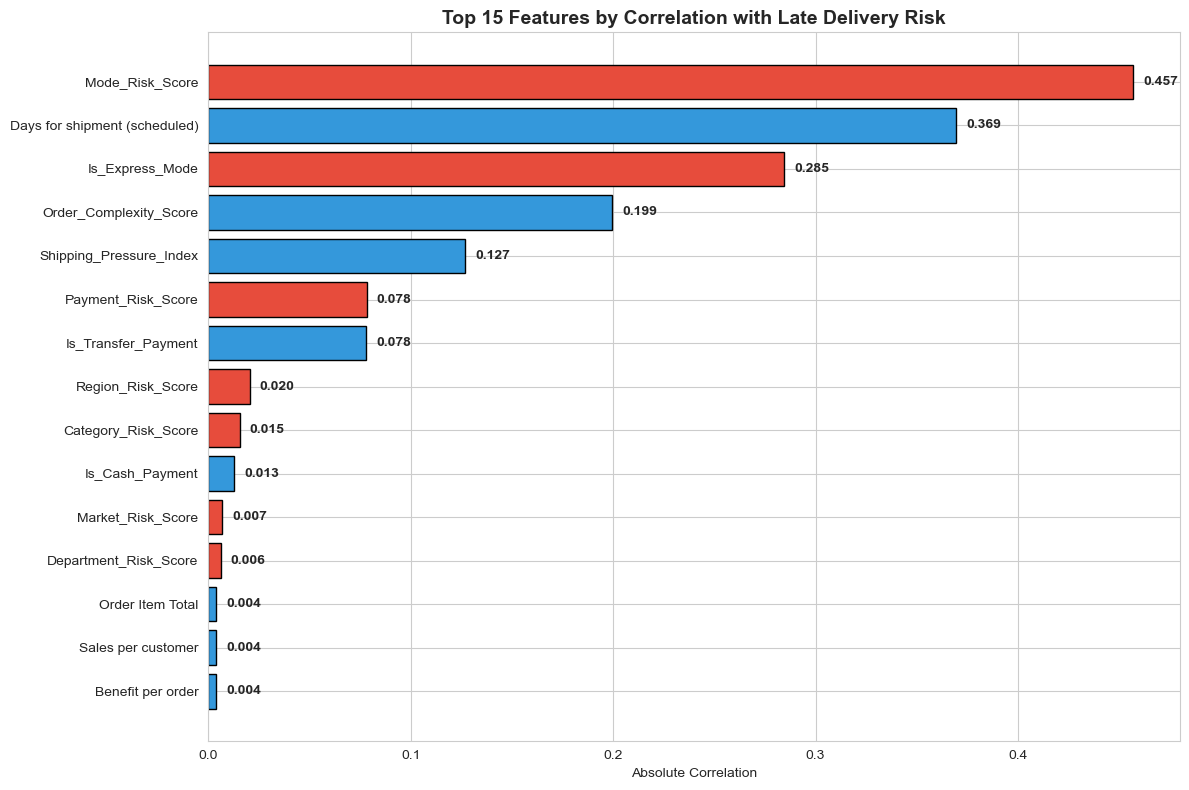


💡 INSIGHT: Features with high correlation are strong predictors!
These are the features the ML model will rely on most heavily.


In [13]:
# ===== VISUALIZE FEATURE IMPORTANCE (correlation with target) =====

# Get only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['Late_delivery_risk'].abs().sort_values(ascending=False)

# Remove the target itself
correlations = correlations[correlations.index != 'Late_delivery_risk']

# Top 15 most correlated features
top_features = correlations.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if 'Risk' in idx or 'Late' in idx or 'Express' in idx else '#3498db' 
          for idx in top_features.index]

ax.barh(top_features.index, top_features.values, color=colors, edgecolor='black')
ax.set_title('Top 15 Features by Correlation with Late Delivery Risk', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

for i, (idx, val) in enumerate(top_features.items()):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/14_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Features with high correlation are strong predictors!")
print("These are the features the ML model will rely on most heavily.")

In [14]:
# ===== SAVE FINAL ENGINEERED DATASET =====

output_path = '../data/APL_Logistics_engineered.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f"✅ Engineered dataset saved!")
print(f"📁 Location: {output_path}")
print(f"📊 Final shape: {df.shape}")
print(f"   Original features: 24")
print(f"   New features:     18")
print(f"   Total:             {df.shape[1]}")

✅ Engineered dataset saved!
📁 Location: ../data/APL_Logistics_engineered.csv
📊 Final shape: (180519, 42)
   Original features: 24
   New features:     18
   Total:             42


In [15]:
# Save phase 5 summary
summary = f"""
PHASE 5 SUMMARY — Feature Engineering Complete
================================================
INPUT:  APL_Logistics_cleaned.csv (24 columns)
OUTPUT: APL_Logistics_engineered.csv ({df.shape[1]} columns)

NEW FEATURES CREATED (18 total):

1. SHIPPING PRESSURE & MODE FEATURES:
   - Shipping_Pressure_Index   (quantity / scheduled_days)
   - Mode_Risk_Score           (target-encoded risk per mode)
   - Is_Express_Mode           (binary: Same Day / First Class)

2. GEOGRAPHIC RISK FEATURES:
   - Market_Risk_Score         (target-encoded risk per market)
   - Region_Risk_Score         (target-encoded risk per region)

3. COMPLEXITY FEATURE:
   - Order_Complexity_Score    (weighted composite score)

4. DISCOUNT FEATURES:
   - Is_High_Discount          (binary: discount > 15%)
   - Discount_Severity         (ordinal: 0-4)

5. PROFIT FEATURES:
   - Is_Loss_Order             (binary: negative profit)
   - Profit_Per_Unit           (profit / quantity)
   - Profit_Margin             (cleaned profit ratio)

6. SALES FEATURES:
   - Sales_Category            (ordinal: 0-4 by value)

7. CATEGORY/DEPT FEATURES:
   - Category_Risk_Score
   - Department_Risk_Score

8. PAYMENT FEATURES:
   - Payment_Risk_Score
   - Is_Cash_Payment
   - Is_Transfer_Payment

9. CUSTOMER FEATURES:
   - Segment_Risk_Score

KEY TECHNIQUE USED: Target Encoding
- Replaces categorical columns with numeric risk scores
- More powerful than one-hot encoding for tree-based models
- Caveat: Mention overfitting risk mitigation in research paper

DATA QUALITY:
- Missing values: {df.isnull().sum().sum()}
- Shape: {df.shape}

READY FOR: Phase 6 — Data Preparation (encoding, scaling, splitting)
"""
print(summary)

with open('../phase5_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("\n✅ Saved to phase5_summary.txt")


PHASE 5 SUMMARY — Feature Engineering Complete
INPUT:  APL_Logistics_cleaned.csv (24 columns)
OUTPUT: APL_Logistics_engineered.csv (42 columns)

NEW FEATURES CREATED (18 total):

1. SHIPPING PRESSURE & MODE FEATURES:
   - Shipping_Pressure_Index   (quantity / scheduled_days)
   - Mode_Risk_Score           (target-encoded risk per mode)
   - Is_Express_Mode           (binary: Same Day / First Class)

2. GEOGRAPHIC RISK FEATURES:
   - Market_Risk_Score         (target-encoded risk per market)
   - Region_Risk_Score         (target-encoded risk per region)

3. COMPLEXITY FEATURE:
   - Order_Complexity_Score    (weighted composite score)

4. DISCOUNT FEATURES:
   - Is_High_Discount          (binary: discount > 15%)
   - Discount_Severity         (ordinal: 0-4)

5. PROFIT FEATURES:
   - Is_Loss_Order             (binary: negative profit)
   - Profit_Per_Unit           (profit / quantity)
   - Profit_Margin             (cleaned profit ratio)

6. SALES FEATURES:
   - Sales_Category          